# Lecture 5 — Class Exercise
## Distribution Charts: Airbnb London

> **Push to:** `week05/lecture05_exercise.ipynb`

**Rules:**
1. Cap price outliers at 95th percentile — annotate this
2. Every chart has a **median/mean reference line** with annotation
3. Insight title names the distribution shape or key finding
4. Colour has meaning — don't use colour just for decoration

---


In [3]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('airbnb_london.csv')
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))


Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [4]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))


95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

> 💡 `df_cap[df_cap['room_type'].isin(['Entire home/apt','Private room'])]`


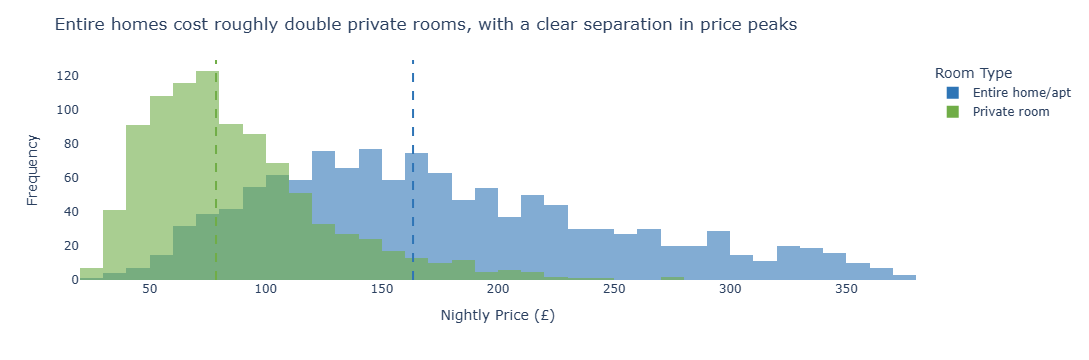

In [5]:
# Task 1
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# 1. Load and Pre-process Data
df = pd.read_csv('airbnb_london.csv')

# Cap price at 95th percentile (Rule 1)
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95].copy()

# Filter for specific room types (Exclude Shared room)
df_t1 = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# 2. Calculate Medians for each group
med_entire = df_t1[df_t1['room_type'] == 'Entire home/apt']['price'].median()
med_private = df_t1[df_t1['room_type'] == 'Private room']['price'].median()

# 3. Create the Plot
fig1 = px.histogram(
    df_t1,
    x='price',
    color='room_type',
    barmode='overlay', # Overlay distributions
    opacity=0.6,
    nbins=40,
    color_discrete_map={'Entire home/apt': '#2E75B6', 'Private room': '#70AD47'},
    labels={'price': 'Nightly Price (£)', 'count': 'Number of Listings'}
)

# 4. Add Median Lines and Annotations
fig1.add_vline(x=med_entire, line_dash='dash', line_color='#2E75B6', line_width=2,
              annotation=dict(text=f'Median Entire: £{med_entire:.0f}', font_color='#2E75B6', yshift=210))

fig1.add_vline(x=med_private, line_dash='dash', line_color='#70AD47', line_width=2,
              annotation=dict(text=f'Median Private: £{med_private:.0f}', font_color='#70AD47', yshift=150))

# 5. Styling and Insight Title
fig1.update_layout(
    title='Entire homes cost roughly double private rooms, with a clear separation in price peaks',
    plot_bgcolor='white',
    xaxis_title='Nightly Price (£)',
    yaxis_title='Frequency',
    legend_title='Room Type'
)

fig1.show()


Task 1: Histogram (Price by Room Type)
This task compares the price distributions of "Entire home/apt" and "Private room" using an overlapping histogram with median reference lines.

## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs

> 💡 Some listings have zero reviews — these are new or inactive listings. Filter them out with before plotting

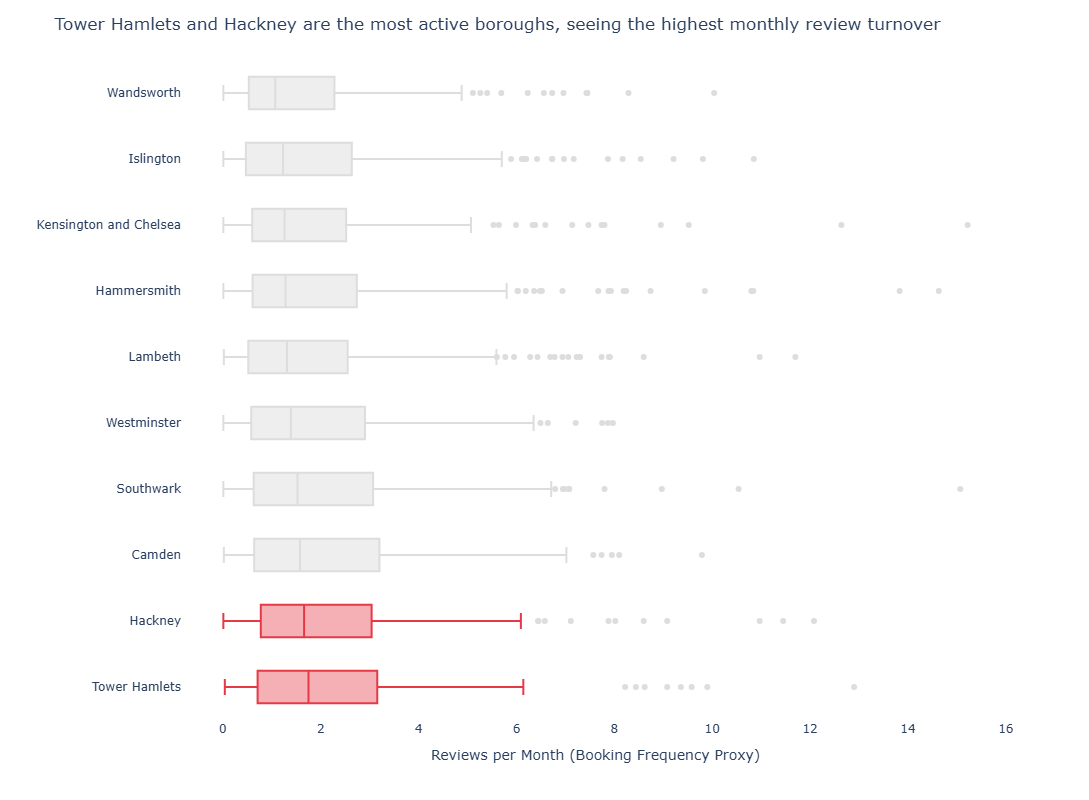

In [6]:
# Task 2
# YOUR CODE HERE
import pandas as pd
import plotly.express as px

# 1. Pre-processing
df = pd.read_csv('airbnb_london.csv')

# Filter out listings with zero reviews
df_t2 = df[df['reviews_per_month'] > 0].copy()

# Calculate median activity per neighbourhood for sorting
med_activity = df_t2.groupby('neighbourhood')['reviews_per_month'].median().sort_values(ascending=True)
sorted_boroughs = med_activity.index.tolist()

# Identify the two most active boroughs
top_2 = med_activity.tail(2).index.tolist()

# 2. Create the Horizontal Box Plot
fig2 = px.box(
    df_t2,
    y='neighbourhood',
    x='reviews_per_month',
    color='neighbourhood',
    category_orders={'neighbourhood': sorted_boroughs},
    color_discrete_sequence=['#DDDDDD'] * len(sorted_boroughs), # Default all to grey
    orientation='h',
    points='outliers', # Show outliers individually
    labels={'reviews_per_month': 'Reviews per Month', 'neighbourhood': ''}
)

# 3. Highlight the two most active boroughs
for trace in fig2.data:
    if trace.name in top_2:
        trace.line.color = '#E63946' # Highlight color
        trace.fillcolor = 'rgba(230,57,70,0.4)'

# 4. Styling and Insight Title
fig2.update_layout(
    title=f'{top_2[1]} and {top_2[0]} are the most active boroughs, seeing the highest monthly review turnover',
    xaxis_title='Reviews per Month (Booking Frequency Proxy)',
    showlegend=False,
    plot_bgcolor='white',
    height=800 # Increased height for many boroughs
)

fig2.show()


Task 2: Box Plot (Listing Activity by Borough)
This task creates a horizontal box plot showing "reviews per month" (activity) across boroughs, sorted by median and highlighting the top 2 most active areas.